In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
participants = pd.read_csv("data/participants.csv")
sleep = pd.read_csv("data/sleep.csv")
surveys = pd.read_csv("data/surveys.csv")
wearables = pd.read_csv("data/wearables.csv")

I picked the participants, sleep, surveys, and wearables data because they give a good picture of the participants as a whole, and use data points that I can understand more easily. I also want to look more into how sleep might affect their symptoms, so with this focus in mind these datasets made the most sense for me.

The feature meanings of the datasets provided are all fairly straightforward. Extensive definitions can be found in the source github: https://github.com/Welltory/hrv-covid19/blob/master/datatypes.md. This link is primarily useful to define the different symptom codes, as these are not explicitly defined in the tables themselves.

### Clean the participants data

In [3]:
participants.head()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


In [4]:
print("Data Structure")
print("---------------")
print(f"Dimensions: {participants.shape}")
print(f"Data Types:\n{participants.dtypes}")
print(f"Missing Values:\n{participants.isnull().sum()}")

Data Structure
---------------
Dimensions: (185, 8)
Data Types:
user_code             str
gender                str
age_range             str
city                  str
country               str
height            float64
weight            float64
symptoms_onset        str
dtype: object
Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64


In [5]:
# height if null does not make sense to me, for my analysis I will not be using city or country but may use height
participants.dropna(subset=['height'], inplace=True)

In [6]:
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {participants.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(participants.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
               most_frequent_value
user_code               007b8190cf
gender                           f
age_range                    35-44
city                        Moscow
country                     Russia
height                       168.0
weight                        60.0
symptoms_onset            5/6/2020


In [7]:
participants.describe()

,height,weight
count,183.000000,183.000000
mean,169.976393,77.986656
std,12.400103,19.648165
min,132.080000,43.500000
25%,163.500000,63.250000
50%,168.000000,74.344000
75%,174.500000,90.668500
max,250.000000,154.221000


In [8]:
# variable relationships
participants.corr(numeric_only=True)

,height,weight
height,1.000000,0.227413
weight,0.227413,1.000000


### Same steps for sleep, surveys, and wearables

In [9]:
# initialize to make looping easier
dataset_dict = {
    "participants": participants,
    "sleep": sleep,
    "surveys": surveys,
    "wearables": wearables
}

In [10]:
print("Data Structure for sleep")
print("---------------")
print(f"Dimensions: {sleep.shape}")
print(f"Data Types:\n{sleep.dtypes}")
print(f"Missing Values:\n{sleep.isnull().sum()}")

Data Structure for sleep
---------------
Dimensions: (425, 12)
Data Types:
user_code                   str
day                         str
sleep_begin                 str
sleep_end                   str
sleep_duration          float64
sleep_awake_duration    float64
sleep_rem_duration      float64
sleep_light_duration    float64
sleep_deep_duration     float64
pulse_min               float64
pulse_max               float64
pulse_average           float64
dtype: object
Missing Values:
user_code                 0
day                       0
sleep_begin               0
sleep_end                 0
sleep_duration            0
sleep_awake_duration    416
sleep_rem_duration      418
sleep_light_duration    398
sleep_deep_duration     411
pulse_min               410
pulse_max               410
pulse_average           410
dtype: int64


In [11]:
sleep.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5


In [12]:
sleep.dropna(subset=["sleep_duration"], inplace=True)
sleep.fillna({"sleep_awake_duration": 0, "sleep_rem_duration": 0, "sleep_light_duration": 0, "sleep_deep_duration": 0}, inplace=True)
print("imputed 0 for sleep statistics, dropped null sleep durations")

imputed 0 for sleep statistics, dropped null sleep durations


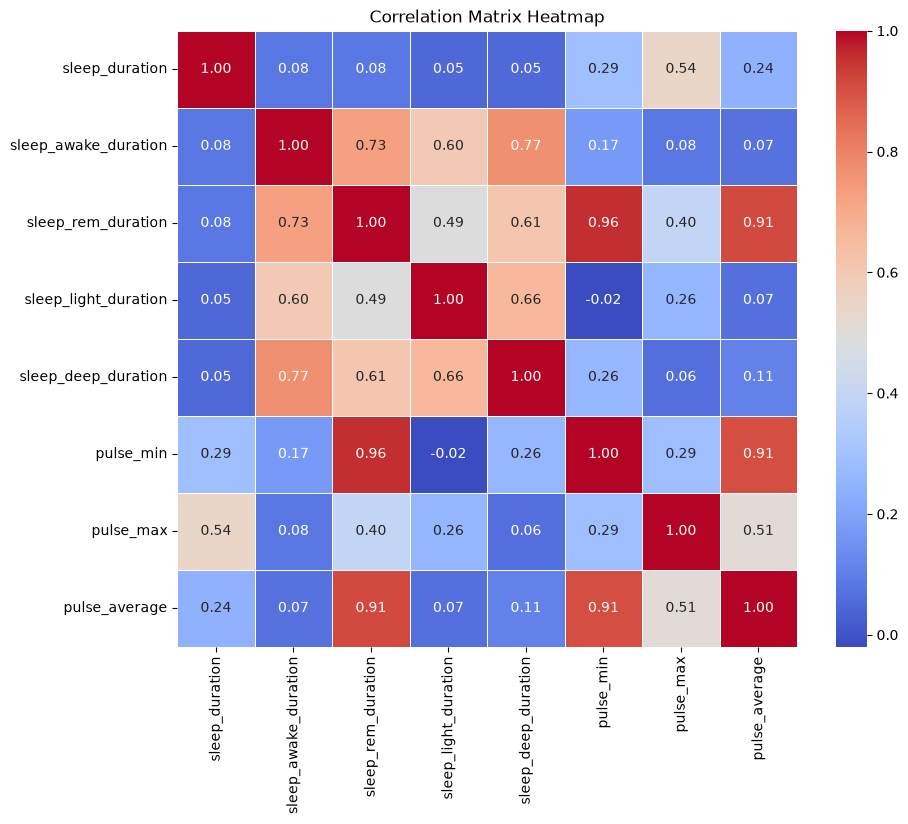

In [13]:
sleep_corr = sleep.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(sleep_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

There seem to be some interesting relationships here, as sleep_rem_duration and sleep_awake_duration are positively correlated, but intuition makes it seem like that would be negatively correlated. Similarly, higher average pulse correlates positively with sleep_rem_duraiton which is an interesting relationship.

In [14]:
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {sleep.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(sleep.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                      most_frequent_value
user_code                      6be5033971
day                            2020-05-15
sleep_begin           2020-05-19 00:03:00
sleep_end             2019-12-31 08:45:22
sleep_duration                    36600.0
sleep_awake_duration                  0.0
sleep_rem_duration                    0.0
sleep_light_duration                  0.0
sleep_deep_duration                   0.0
pulse_min                            60.0
pulse_max                            94.0
pulse_average                      65.857


In [15]:
print("Data Structure for surveys")
print("---------------")
print(f"Dimensions: {surveys.shape}")
print(f"Data Types:\n{surveys.dtypes}")
print(f"Missing Values:\n{surveys.isnull().sum()}")

Data Structure for surveys
---------------
Dimensions: (2259, 5)
Data Types:
user_code       str
scale           str
created_at      str
value         int64
text            str
dtype: object
Missing Values:
user_code     0
scale         0
created_at    0
value         0
text          0
dtype: int64


In [16]:
surveys.head()

,user_code,scale,created_at,value,text
0,01bad5a519,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,S_COVID_BLUISH,2020-04-25,1,User isn’t experiencing symptom
3,01bad5a519,S_COVID_BLUISH,2020-04-27,1,User isn’t experiencing symptom
4,01bad5a519,S_COVID_BLUISH,2020-04-29,1,User isn’t experiencing symptom


In [17]:
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {surveys.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(surveys.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                        most_frequent_value
user_code                        6be5033971
scale                       S_COVID_FATIGUE
created_at                       2020-05-03
value                                     1
text        User isn’t experiencing symptom


Very clean dataset, nothing more I want to do here

In [18]:
print("Data Structure for wearables")
print("---------------")
print(f"Dimensions: {wearables.shape}")
print(f"Data Types:\n{wearables.dtypes}")
print(f"Missing Values:\n{wearables.isnull().sum()}")

Data Structure for wearables
---------------
Dimensions: (3098, 18)
Data Types:
user_code                              str
day                                    str
resting_pulse                      float64
pulse_average                      float64
pulse_min                          float64
pulse_max                          float64
average_spo2_value                 float64
body_temperature_avg               float64
stand_hours_total                  float64
steps_count                        float64
distance                           float64
steps_speed                        float64
total_number_of_flights_climbed    float64
active_calories_burned             float64
basal_calories_burned              float64
total_calories_burned              float64
average_headphone_exposure         float64
average_environment_exposure       float64
dtype: object
Missing Values:
user_code                             0
day                                   0
resting_pulse                      1

In [19]:
# dropping na columns leads to an empty dataset, we will instead filter the dataframe down
wearables.head()

,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure
0,007b8190cf,2020-04-26,NaN,70.0,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2859.0,2859.0,NaN,NaN
1,01bad5a519,2020-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8574.0,NaN,57.90,NaN,NaN,2624.0,2624.0,NaN,NaN
2,01bad5a519,2020-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7462.0,NaN,59.10,NaN,NaN,2624.0,2624.0,NaN,NaN
3,01bad5a519,2020-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507.0,NaN,60.97,NaN,NaN,2624.0,2624.0,NaN,NaN
4,01bad5a519,2020-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10131.0,NaN,49.10,NaN,NaN,2624.0,2624.0,NaN,NaN


In [20]:
wearables_filtered = wearables[
    ["user_code", "day", "pulse_average", "body_temperature_avg", "steps_count", "total_calories_burned", "active_calories_burned"]
]
wearables_filtered.describe()

,pulse_average,body_temperature_avg,steps_count,total_calories_burned,active_calories_burned
count,2089.000000,65.000000,1968.000000,3097.00000,1200.000000
mean,78.084251,36.404615,5342.067581,2549.04908,750.721667
std,14.366994,0.239394,4761.774987,804.62248,915.538000
min,48.000000,35.800000,1.000000,81.00000,1.000000
25%,69.000000,36.200000,1456.000000,2001.00000,66.000000
50%,76.000000,36.400000,4477.500000,2353.00000,180.000000
75%,85.000000,36.600000,7857.250000,2668.00000,1597.000000
max,163.000000,36.900000,30882.000000,8418.00000,5423.000000


In [21]:
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {wearables_filtered.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(wearables_filtered.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                       most_frequent_value
user_code                       0d297d2410
day                             2020-05-03
pulse_average                         76.0
body_temperature_avg                  36.6
steps_count                            8.0
total_calories_burned               2624.0
active_calories_burned              1447.0


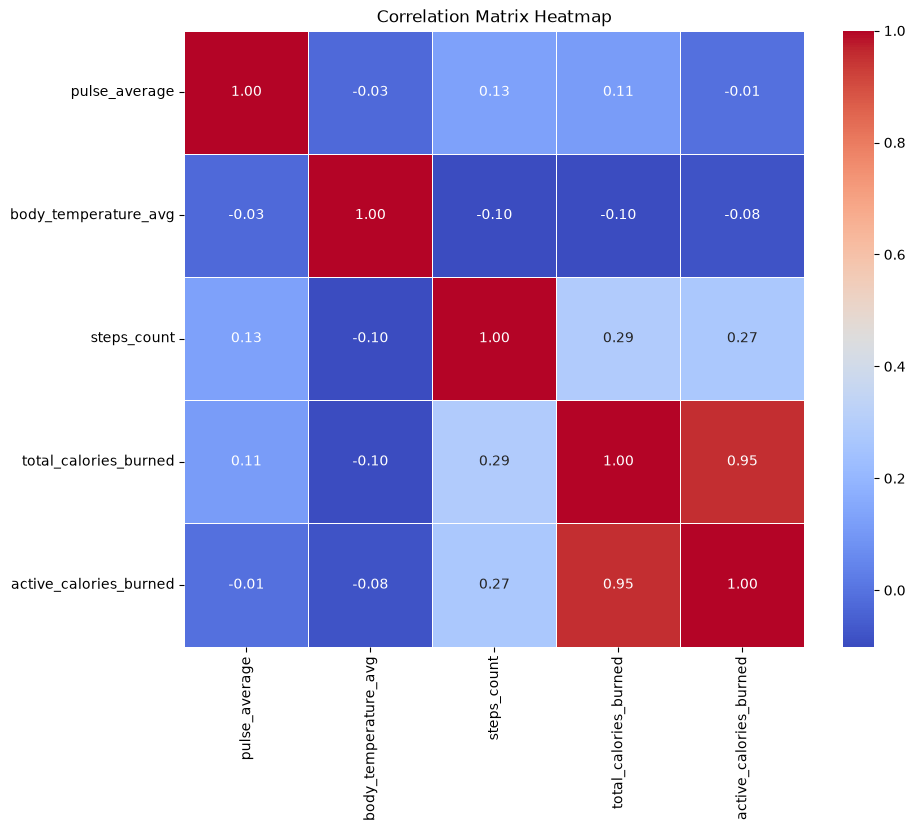

In [22]:
wearbles_corr = wearables_filtered.drop(columns=["user_code", "day"]).corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(wearbles_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

The filtered dataset is clean and good for me, I pulled the features I wanted which cleaned it up well. No real relationships besides trivial ones, little correlation in this dataframe

### Merge Datasets and Analyze

In [23]:
for dataset_name in dataset_dict:
    df = dataset_dict[dataset_name]
    print(f"Number of rows in {dataset_name}: {len(df)}")

Number of rows in participants: 183
Number of rows in sleep: 425
Number of rows in surveys: 2259
Number of rows in wearables: 3098


In [24]:
wearables_filtered.head()

,user_code,day,pulse_average,body_temperature_avg,steps_count,total_calories_burned,active_calories_burned
0,007b8190cf,2020-04-26,70.0,NaN,NaN,2859.0,NaN
1,01bad5a519,2020-02-12,NaN,NaN,8574.0,2624.0,NaN
2,01bad5a519,2020-02-13,NaN,NaN,7462.0,2624.0,NaN
3,01bad5a519,2020-02-15,NaN,NaN,2507.0,2624.0,NaN
4,01bad5a519,2020-02-16,NaN,NaN,10131.0,2624.0,NaN


In [25]:
sleep.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,0.0,0.0,21480.0,0.0,55.0,95.0,72.5


In [26]:
sleep_wearables = pd.merge(sleep, wearables_filtered, on=["user_code", "day"], how="right")
sleep_wearables.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average_x,pulse_average_y,body_temperature_avg,steps_count,total_calories_burned,active_calories_burned
0,007b8190cf,2020-04-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,NaN,NaN,2859.0,NaN
1,01bad5a519,2020-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8574.0,2624.0,NaN
2,01bad5a519,2020-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7462.0,2624.0,NaN
3,01bad5a519,2020-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507.0,2624.0,NaN
4,01bad5a519,2020-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10131.0,2624.0,NaN


In [27]:
participants.head()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


In [28]:
surveys.head()

,user_code,scale,created_at,value,text
0,01bad5a519,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,S_COVID_BLUISH,2020-04-25,1,User isn’t experiencing symptom
3,01bad5a519,S_COVID_BLUISH,2020-04-27,1,User isn’t experiencing symptom
4,01bad5a519,S_COVID_BLUISH,2020-04-29,1,User isn’t experiencing symptom


In [29]:
merged = pd.merge(sleep_wearables, surveys, left_on=["user_code", "day"], right_on=["user_code", "created_at"])
merged.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,...,pulse_average_x,pulse_average_y,body_temperature_avg,steps_count,total_calories_burned,active_calories_burned,scale,created_at,value,text
0,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,82.0,NaN,275.0,2624.0,NaN,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,82.0,NaN,275.0,2624.0,NaN,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,82.0,NaN,275.0,2624.0,NaN,S_COVID_BREATH,2020-04-23,3,Mild
3,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,82.0,NaN,275.0,2624.0,NaN,S_COVID_CONFUSION,2020-04-23,1,User isn’t experiencing symptom
4,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,82.0,NaN,275.0,2624.0,NaN,S_COVID_COUGH,2020-04-23,2,Very mild


In [30]:
merged = pd.merge(merged, participants, on=["user_code"])
merged.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,...,created_at,value,text,gender,age_range,city,country,height,weight,symptoms_onset
0,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2020-04-23,2,Symptoms are characteristic of coronavirus,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020
1,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2020-04-23,1,User isn’t experiencing symptom,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020
2,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2020-04-23,3,Mild,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020
3,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2020-04-23,1,User isn’t experiencing symptom,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020
4,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2020-04-23,2,Very mild,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020


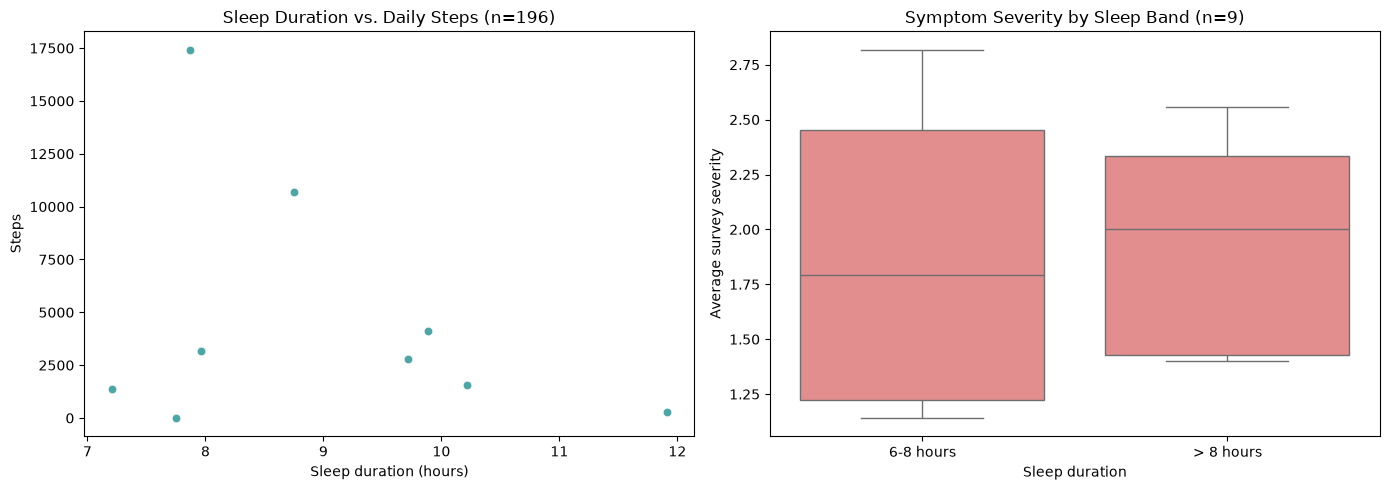

Daily records used for the steps plot: 196
Participant-days used for the symptom plot: 9


In [31]:
# A couple of focused views using the merged dataset
merged_daily = merged.drop_duplicates(subset=["user_code", "day"]).copy()
merged_daily["sleep_hours"] = merged_daily["sleep_duration"] / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Insight 1: compare sleep duration with daily activity
sns.scatterplot(
    data=merged_daily,
    x="sleep_hours",
    y="steps_count",
    alpha=0.7,
    color="teal",
    ax=axes[0]
)
axes[0].set_title(f"Sleep Duration vs. Daily Steps (n={len(merged_daily)})")
axes[0].set_xlabel("Sleep duration (hours)")
axes[0].set_ylabel("Steps")

# Insight 2: compare average reported symptom severity across sleep bands
symptoms_daily = (
    merged.dropna(subset=["value"])
    .groupby(["user_code", "day"], as_index=False)
    .agg(
        sleep_duration=("sleep_duration", "first"),
        symptom_severity=("value", "mean")
    )
)
symptoms_daily["sleep_hours"] = symptoms_daily["sleep_duration"] / 3600
symptoms_daily["sleep_band"] = pd.cut(
    symptoms_daily["sleep_hours"],
    bins=[0, 6, 8, np.inf],
    labels=["< 6 hours", "6-8 hours", "> 8 hours"]
)
symptoms_daily = symptoms_daily.dropna(subset=["sleep_band"])
observed_bands = [band for band in ["< 6 hours", "6-8 hours", "> 8 hours"]
                  if band in symptoms_daily["sleep_band"].astype(str).unique()]
sns.boxplot(
    data=symptoms_daily,
    x="sleep_band",
    y="symptom_severity",
    order=observed_bands,
    color="lightcoral",
    ax=axes[1]
)
axes[1].set_title(f"Symptom Severity by Sleep Band (n={len(symptoms_daily)})")
axes[1].set_xlabel("Sleep duration")
axes[1].set_ylabel("Average survey severity")

plt.tight_layout()
plt.show()

print("Daily records used for the steps plot:", len(merged_daily))
print("Participant-days used for the symptom plot:", len(symptoms_daily))

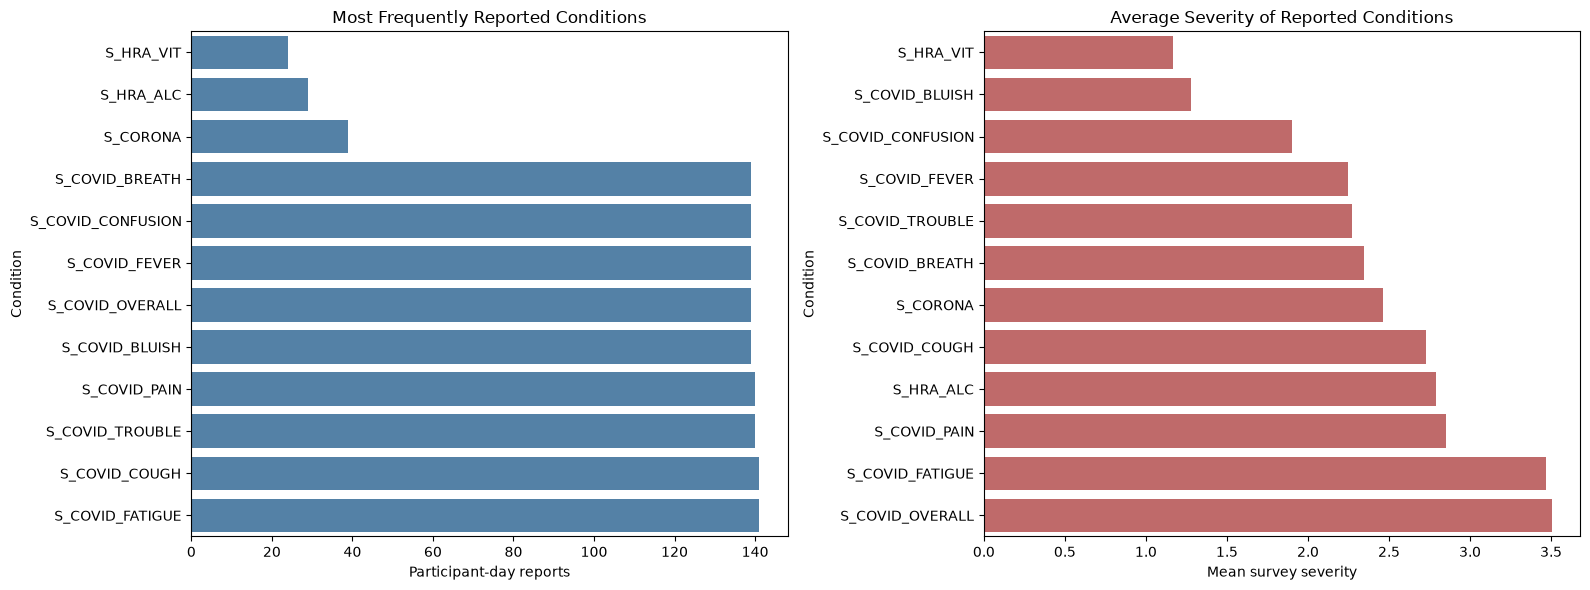

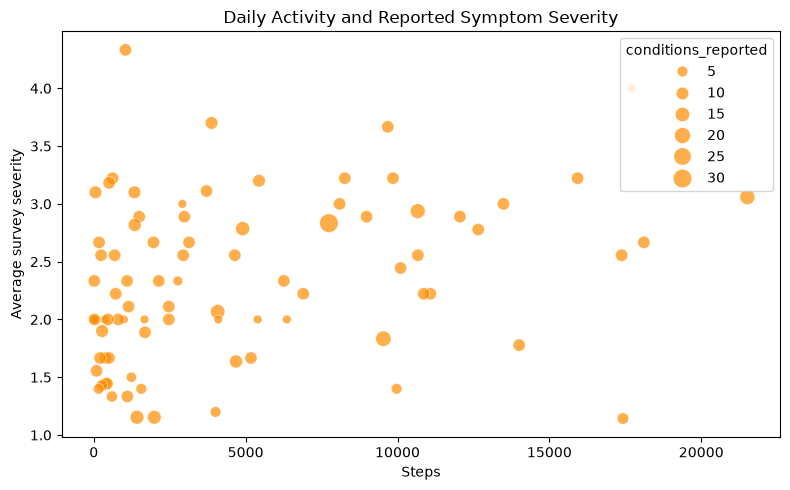

Unique participant-day survey records: 1500
Complete daily activity/symptom records: 84


In [34]:
# Meaningful merged-data summaries
survey_records = merged[["user_code", "day", "scale", "value"]].drop_duplicates()
condition_summary = (
    survey_records.groupby("scale", as_index=False)
    .agg(
        reports=("value", "size"),
        average_severity=("value", "mean")
    )
    .sort_values("reports", ascending=False)
    .head(12)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=condition_summary.sort_values("reports"),
    x="reports",
    y="scale",
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("Most Frequently Reported Conditions")
axes[0].set_xlabel("Participant-day reports")
axes[0].set_ylabel("Condition")

severity_order = condition_summary.sort_values("average_severity")
sns.barplot(
    data=severity_order,
    x="average_severity",
    y="scale",
    color="indianred",
    ax=axes[1]
)
axes[1].set_title("Average Severity of Reported Conditions")
axes[1].set_xlabel("Mean survey severity")
axes[1].set_ylabel("Condition")

plt.tight_layout()
plt.show()

pulse_column = next(
    column for column in ["pulse_average_y", "pulse_average_x", "pulse_average"]
    if column in merged.columns
)
daily_symptoms = (
    merged.groupby(["user_code", "day"], as_index=False)
    .agg(
        steps=("steps_count", "first"),
        average_pulse=(pulse_column, "first"),
        symptom_severity=("value", "mean"),
        conditions_reported=("scale", "nunique")
    )
    .dropna(subset=["steps", "average_pulse", "symptom_severity"])
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=daily_symptoms,
    x="steps",
    y="symptom_severity",
    size="conditions_reported",
    sizes=(40, 180),
    alpha=0.7,
    color="darkorange"
)
plt.title("Daily Activity and Reported Symptom Severity")
plt.xlabel("Steps")
plt.ylabel("Average survey severity")
plt.tight_layout()
plt.show()

print("Unique participant-day survey records:", len(survey_records))
print("Complete daily activity/symptom records:", len(daily_symptoms))

New feature: Symptom Burden

Created as the sum of the symptom severities on a given day, shows how bad the symptoms as a whole are for a given person. This allows us to analyze is things like activity and sleep lead to higher or lower symptom burden as a whole.

In [40]:
merged["symptom_burden"] = merged.groupby(['user_code', 'day'])['value'].transform('sum')
merged["average_symptom_severity"] = merged.groupby(['user_code', 'day'])['value'].transform('mean')
merged.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,...,text,gender,age_range,city,country,height,weight,symptoms_onset,symptom_burden,average_symptom_severity
0,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Symptoms are characteristic of coronavirus,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020,19,1.9
1,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,User isn’t experiencing symptom,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020,19,1.9
2,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Mild,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020,19,1.9
3,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,User isn’t experiencing symptom,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020,19,1.9
4,01bad5a519,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Very mild,m,45-54,St Petersburg,Russia,178.0,92.0,4/5/2020,19,1.9


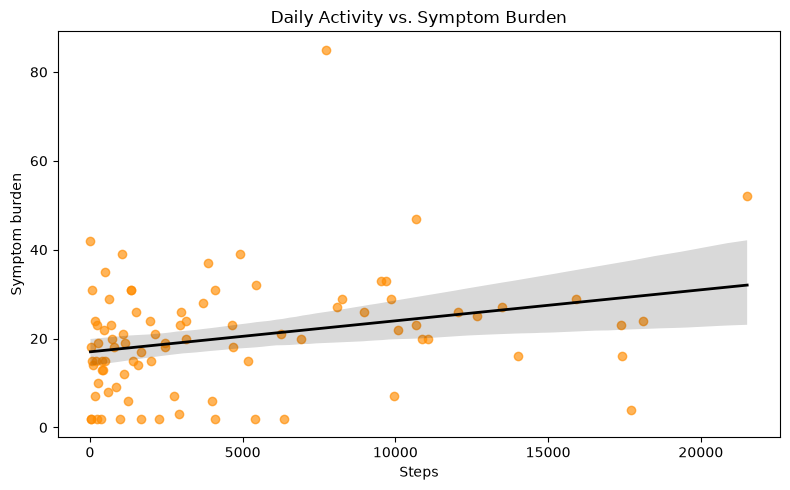

Complete participant-days: 89
Correlation: 0.2812429972113363


In [39]:
# Relationship between daily activity and total symptom burden
burden_daily = (
    merged[["user_code", "day", "steps_count", "symptom_burden"]]
    .drop_duplicates(subset=["user_code", "day"])
    .dropna(subset=["steps_count", "symptom_burden"])
)

plt.figure(figsize=(8, 5))
sns.regplot(
    data=burden_daily,
    x="steps_count",
    y="symptom_burden",
    scatter_kws={"alpha": 0.65, "color": "darkorange"},
    line_kws={"color": "black", "linewidth": 2}
)
plt.title("Daily Activity vs. Symptom Burden")
plt.xlabel("Steps")
plt.ylabel("Symptom burden")
plt.tight_layout()
plt.show()

print("Complete participant-days:", len(burden_daily))
print("Correlation:", burden_daily["steps_count"].corr(burden_daily["symptom_burden"]))

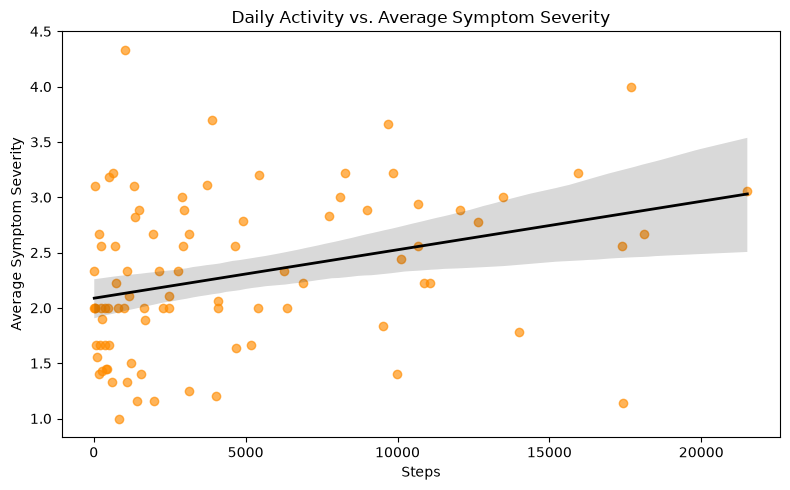

Complete participant-days: 89
Correlation: 0.32563703220501133


In [41]:
# Relationship between daily activity and total symptom burden
average_symptoms = (
    merged[["user_code", "day", "steps_count", "average_symptom_severity"]]
    .drop_duplicates(subset=["user_code", "day"])
    .dropna(subset=["steps_count", "average_symptom_severity"])
)

plt.figure(figsize=(8, 5))
sns.regplot(
    data=average_symptoms,
    x="steps_count",
    y="average_symptom_severity",
    scatter_kws={"alpha": 0.65, "color": "darkorange"},
    line_kws={"color": "black", "linewidth": 2}
)
plt.title("Daily Activity vs. Average Symptom Severity")
plt.xlabel("Steps")
plt.ylabel("Average Symptom Severity")
plt.tight_layout()
plt.show()

print("Complete participant-days:", len(average_symptoms))
print("Correlation:", average_symptoms["steps_count"].corr(average_symptoms["average_symptom_severity"]))

## Discussions

### Data Context and Sampling

The data collected for this project was collected from COVID-positive patients who tracked their data using the data collector's app. This is a form of convenience sampling that may possibly lead to bias in the data. Also, this means there is a limitation in the dataset where we do not see data from before their symptoms onset.

### Datasets Chosen:

As explained earlier, I chose the wearables and sleep data to analyze because I was interested in how activity and sleep may impact the symptoms that people experienced, and whether or not they got sick at all. I did not choose some of the other datasets, like blood pressure for example, because I am less familiar with what the data actually means in those due to my lack of healthcare knowledge.

### Data Quality:

The data quality of each table varied greatly. Participants and surveys had great quality overall, missing few values if at all and being generally clean. Sleep and wearbles were both missing a good amount of data, some that was dropped and some that was imputed. This is likely due to the issues that come from tracking data on sleep or activity primarily through a wearble. Merging the data led to a lot of rows being dropped, hinting to issues with consistency or simply a lack of data over a large enough time range to provide meaningful insights.

In terms of accuracy and integrity, the data seems to have good quality. There may be some issues as talked about earlier in the notebook regarding interesting/confusing correlations, but this may be due to my lack of knowledge on healthcare instead of on inaccurate data provided.

### Data Analysis and Feature Engineering

Some interesting findings were found from these datasets. Some findings were that reported severity of fatigue and cough, as well as overall COVID, were quite high. This may be due to the higher prevalence of these symptoms, and those being surveyed saying the symptoms are worse than they maybe really are.

For feature engineering, I created a variable called symptom burden. This summed all the symptom severities for a given person on a given day, to see how much a person is feeling with their symptoms as a whole. I also created a variable for average severity. These were both analyzed against step count, and while there is a positive correlation, it is small and more likely due to most data points having lower step counts. However, people doing more activity instead of resting when sick may also lead to more severity, so more data would be needed to confirm.